In [15]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project imports
from config.config import Config
from src.data_loader import StockDataLoader
from src.data_preprocessor import StockDataPreprocessor
from src.model import LSTMStockModel

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("✓ Imports successful")

TensorFlow version: 2.19.0
GPU available: []
✓ Imports successful


In [16]:
# Initialize configuration with enhanced parameters
config = Config()

# Override configuration for better performance
config.preprocessing.sequence_length = 30  # Increased from 12
config.preprocessing.add_technical_indicators = True

# Enhanced model configuration
config.model.model_type = "deep_lstm"  # Using deeper architecture
config.model.lstm_units = [128, 128, 64, 32]  # More units
config.model.dropout_rate = 0.3  # Increased dropout
config.model.learning_rate = 0.0005  # Lower learning rate

# Training configuration
config.training.epochs = 200  # More epochs
config.training.batch_size = 32
config.training.early_stopping_patience = 25
config.training.reduce_lr_patience = 15

print("=" * 60)
print("ENHANCED CONFIGURATION")
print("=" * 60)
print(f"\nPreprocessing:")
print(f"  - Sequence length: {config.preprocessing.sequence_length}")
print(f"  - Technical indicators: {config.preprocessing.add_technical_indicators}")

print(f"\nModel:")
print(f"  - Model type: {config.model.model_type}")
print(f"  - LSTM units: {config.model.lstm_units}")
print(f"  - Dropout rate: {config.model.dropout_rate}")
print(f"  - Learning rate: {config.model.learning_rate}")

print(f"\nTraining:")
print(f"  - Epochs: {config.training.epochs}")
print(f"  - Batch size: {config.training.batch_size}")

ENHANCED CONFIGURATION

Preprocessing:
  - Sequence length: 30
  - Technical indicators: True

Model:
  - Model type: deep_lstm
  - LSTM units: [128, 128, 64, 32]
  - Dropout rate: 0.3
  - Learning rate: 0.0005

Training:
  - Epochs: 200
  - Batch size: 32


# 3. Load and Prepare Data with Technical Indicators

In [17]:
# Load data
data_path = project_root / config.data.raw_data_path
print(f"Loading data from: {data_path}")

data_loader = StockDataLoader(str(data_path))
df = data_loader.load_csv(date_column=config.data.date_column)

print(f"\n✓ Loaded {len(df):,} records")
print(f"✓ Date range: {df[config.data.date_column].min()} to {df[config.data.date_column].max()}")

# Create preprocessor
preprocessor = StockDataPreprocessor(
    feature_columns=config.data.feature_columns,
    target_column=config.data.target_column
)

# Handle missing values
df = preprocessor.handle_missing_values(df, method=config.preprocessing.missing_value_method)

# Add comprehensive technical indicators
print("\nAdding technical indicators...")
df_enhanced = preprocessor.add_technical_indicators(df)

print(f"\n✓ Enhanced data shape: {df_enhanced.shape}")
print(f"✓ Total features: {len(df_enhanced.columns)}")
print(f"\nFeatures added: {list(df_enhanced.columns)}")

df_enhanced.head()

INFO:src.data_loader:Loaded 245 records from c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv
INFO:src.data_preprocessor:Added comprehensive technical indicators. New shape: (216, 41)
INFO:src.data_preprocessor:Total features: 41


Loading data from: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv

✓ Loaded 245 records
✓ Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00

Adding technical indicators...

✓ Enhanced data shape: (216, 41)
✓ Total features: 41

Features added: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_14', 'MA_21', 'MA_30', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'Volatility_7', 'Volatility_14', 'Volatility_30', 'Momentum_1', 'Momentum_5', 'Momentum_10', 'ROC_5', 'ROC_10', 'ATR', 'Volume_MA_7', 'Volume_MA_14', 'Volume_Ratio', 'OBV', 'Pct_Change_1', 'Pct_Change_5', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_7']


,Date,Open,High,Low,Close,Volume,MA_7,MA_14,MA_21,MA_30,...,Volume_MA_14,Volume_Ratio,OBV,Pct_Change_1,Pct_Change_5,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_7
29,2002-06-01,141.990431,48.242823,43.919856,142.301435,29741.0,108.416398,86.978771,71.911987,71.723204,...,17319.071429,1.717240,86835.0,0.329240,0.591154,107.054726,47.447761,79.762376,89.432836,152.436548
30,2002-07-01,95.259434,59.207547,56.059198,95.240566,20191.0,92.285875,91.733922,73.555761,71.469212,...,18378.357143,1.098629,66644.0,-0.330713,0.123631,142.301435,107.054726,47.447761,84.761421,208.154229
31,2002-08-01,109.132075,60.087264,54.754245,109.429245,23199.0,95.142505,96.594750,75.886749,72.355946,...,19479.785714,1.190927,89843.0,0.148977,0.371941,95.240566,142.301435,107.054726,79.762376,89.432836
32,2002-09-01,239.963636,58.180682,50.203409,245.218182,53948.0,118.064899,111.998246,85.527343,78.150698,...,22921.357143,2.353613,143791.0,1.240883,4.168172,109.429245,95.240566,142.301435,47.447761,84.761421
33,2002-10-01,179.355856,58.805180,53.012387,173.842342,38593.0,131.504894,121.266747,91.902660,82.633171,...,25073.428571,1.539199,105198.0,-0.291071,0.623864,245.218182,109.429245,95.240566,107.054726,79.762376


## 4. Feature Selection and Scaling

In [18]:
# Select all numeric features except date
feature_cols = [col for col in df_enhanced.columns if col not in [config.data.date_column]]
target_col = config.data.target_column

print(f"Total features for training: {len(feature_cols)}")
print(f"Target column: {target_col}")

# Extract features and target
features = df_enhanced[feature_cols].values
target = df_enhanced[target_col].values.reshape(-1, 1)

print(f"\nFeatures shape: {features.shape}")
print(f"Target shape: {target.shape}")

# Scale features
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(features)

# Scale target
target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(target)

print(f"\n✓ Scaled features shape: {scaled_features.shape}")
print(f"✓ Scaled target shape: {scaled_target.shape}")

# Save scalers
scaler_dir = project_root / 'models' / 'scalers_enhanced'
scaler_dir.mkdir(parents=True, exist_ok=True)

import joblib
joblib.dump(feature_scaler, scaler_dir / 'feature_scaler.pkl')
joblib.dump(target_scaler, scaler_dir / 'target_scaler.pkl')
print(f"\n✓ Scalers saved to {scaler_dir}")

Total features for training: 40
Target column: Close

Features shape: (216, 40)
Target shape: (216, 1)

✓ Scaled features shape: (216, 40)
✓ Scaled target shape: (216, 1)

✓ Scalers saved to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\scalers_enhanced


## 5. Create Enhanced Sequences

In [19]:
def create_sequences(features, target, sequence_length):
    """
    Create sequences for LSTM training.
    """
    X, y = [], []
    
    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(target[i])
    
    return np.array(X), np.array(y)

# Create sequences with longer lookback
sequence_length = config.preprocessing.sequence_length
print(f"Creating sequences with length: {sequence_length}")

X, y = create_sequences(scaled_features, scaled_target, sequence_length)

print(f"\n✓ Sequence shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Total samples: {len(X):,}")
print(f"✓ Features per timestep: {X.shape[2]}")

Creating sequences with length: 30

✓ Sequence shape: (186, 30, 40)
✓ Target shape: (186, 1)
✓ Total samples: 186
✓ Features per timestep: 40


## 6. Split Data

In [20]:
# Split into train, validation, and test sets
train_size = int(len(X) * config.preprocessing.train_ratio)
val_size = int(len(X) * config.preprocessing.validation_ratio)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"\nTraining set: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

DATA SPLIT

Training set: (148, 30, 40) (79.6%)
Validation set: (18, 30, 40) (9.7%)
Test set: (20, 30, 40) (10.8%)


## 7. Build Enhanced Deep LSTM Model

In [21]:
# Input shape
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"Input shape: {input_shape}")
print(f"  - Sequence length: {input_shape[0]}")
print(f"  - Number of features: {input_shape[1]}")

# Build deep LSTM model
lstm_model_builder = LSTMStockModel(input_shape=input_shape)

model = lstm_model_builder.build_deep_lstm(
    units=config.model.lstm_units,
    dropout=config.model.dropout_rate
)

# Compile model with custom metrics
optimizer = keras.optimizers.Adam(learning_rate=config.model.learning_rate)
model.compile(
    optimizer=optimizer,
    loss='huber',  # Huber loss is more robust to outliers
    metrics=[
        'mean_absolute_error',
        'mean_absolute_percentage_error',
        keras.metrics.RootMeanSquaredError(name='rmse')
    ]
)

print("\n" + "=" * 60)
print("ENHANCED MODEL ARCHITECTURE")
print("=" * 60)
model.summary()

Input shape: (30, 40)
  - Sequence length: 30
  - Number of features: 40


INFO:src.model:Built deep LSTM model with layers: [128, 128, 64, 32]



ENHANCED MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,945 (1.08 MB)

 Trainable params: 282,241 (1.08 MB)

 Non-trainable params: 704 (2.75 KB)

##  Setup Enhanced Callbacks

In [22]:
# Create directories
model_dir = project_root / 'models' / 'saved_models_enhanced'
checkpoint_dir = project_root / 'models' / 'checkpoints_enhanced'
log_dir = project_root / 'logs' / f'enhanced_training_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

model_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# Define callbacks
callback_list = [
    # Early stopping with more patience
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config.training.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Reduce learning rate
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.training.reduce_lr_patience,
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=1
    ),
    
    # CSV Logger
    callbacks.CSVLogger(
        filename=str(log_dir / 'training_log.csv'),
        separator=',',
        append=False
    )
]

print("✓ Enhanced callbacks configured")
print(f"  - Model checkpoints: {checkpoint_dir}")
print(f"  - Training logs: {log_dir}")

✓ Enhanced callbacks configured
  - Model checkpoints: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints_enhanced
  - Training logs: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\enhanced_training_20260301_114456


## 9. Train Enhanced Model

In [23]:
# Train the model
print("\n" + "=" * 60)
print("STARTING ENHANCED TRAINING")
print("=" * 60)
print(f"Epochs: {config.training.epochs}")
print(f"Batch size: {config.training.batch_size}")
print(f"Model: Deep LSTM with {config.model.lstm_units} units")
print(f"Features: {X_train.shape[2]} technical indicators")
print(f"\nTraining started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=config.training.epochs,
    batch_size=config.training.batch_size,
    callbacks=callback_list,
    verbose=1,
    shuffle=config.training.shuffle
)

print(f"\n✓ Training completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


STARTING ENHANCED TRAINING
Epochs: 200
Batch size: 32
Model: Deep LSTM with [128, 128, 64, 32] units
Features: 40 technical indicators

Training started at: 2026-03-01 11:44:56

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8507 - mean_absolute_error: 0.6580 - mean_absolute_percentage_error: 561.6518 - rmse: 0.8224
Epoch 1: val_loss improved from None to 0.54214, saving model to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints_enhanced\best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step - loss: 0.8776 - mean_absolute_error: 0.6930 - mean_absolute_percentage_error: 565.7021 - rmse: 0.8680 - val_loss: 0.5421 - val_mean_absolute_error: 0.1216 - val_mean_absolute_percentage_error: 125.4734 - val_rmse: 0.1259 - learning_rate: 5.0000e-04
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.8656 - mean_absolute_error: 0.6589 - mean_absolute_percentage_error: 552.8474 - rmse: 0.8923
Epoch 2: val_loss improved fr

## 10. Save Enhanced Model

In [24]:
# Save the final model
model_save_path = model_dir / f'enhanced_lstm_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.keras'
model.save(model_save_path)
print(f"✓ Model saved to: {model_save_path}")

# Save training history
history_df = pd.DataFrame(history.history)
history_csv_path = log_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"✓ Training history saved to: {history_csv_path}")

# Save feature names for reference
feature_names_path = model_dir / 'feature_names.txt'
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(feature_cols))
print(f"✓ Feature names saved to: {feature_names_path}")

✓ Model saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models_enhanced\enhanced_lstm_model_20260301_114801.keras
✓ Training history saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\enhanced_training_20260301_114456\training_history.csv
✓ Feature names saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models_enhanced\feature_names.txt


## 11. Comprehensive Performance Evaluation

In [25]:
# Make predictions on all sets
print("Evaluating model performance...\n")

# Training set
y_pred_train = model.predict(X_train, verbose=0)
y_train_actual = target_scaler.inverse_transform(y_train)
y_pred_train_actual = target_scaler.inverse_transform(y_pred_train)

train_mse = mean_squared_error(y_train_actual, y_pred_train_actual)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_actual, y_pred_train_actual)
train_mape = np.mean(np.abs((y_train_actual - y_pred_train_actual) / y_train_actual)) * 100
train_r2 = r2_score(y_train_actual, y_pred_train_actual)

# Validation set
y_pred_val = model.predict(X_val, verbose=0)
y_val_actual = target_scaler.inverse_transform(y_val)
y_pred_val_actual = target_scaler.inverse_transform(y_pred_val)

val_mse = mean_squared_error(y_val_actual, y_pred_val_actual)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val_actual, y_pred_val_actual)
val_mape = np.mean(np.abs((y_val_actual - y_pred_val_actual) / y_val_actual)) * 100
val_r2 = r2_score(y_val_actual, y_pred_val_actual)

# Test set
y_pred_test = model.predict(X_test, verbose=0)
y_test_actual = target_scaler.inverse_transform(y_test)
y_pred_test_actual = target_scaler.inverse_transform(y_pred_test)

test_mse = mean_squared_error(y_test_actual, y_pred_test_actual)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_actual, y_pred_test_actual)
test_mape = np.mean(np.abs((y_test_actual - y_pred_test_actual) / y_test_actual)) * 100
test_r2 = r2_score(y_test_actual, y_pred_test_actual)

# Display results
print("=" * 80)
print("COMPREHENSIVE PERFORMANCE EVALUATION")
print("=" * 80)

print(f"\n{'Metric':<20} {'Training':<15} {'Validation':<15} {'Test':<15}")
print("-" * 80)
print(f"{'RMSE':<20} {train_rmse:<15.4f} {val_rmse:<15.4f} {test_rmse:<15.4f}")
print(f"{'MAE':<20} {train_mae:<15.4f} {val_mae:<15.4f} {test_mae:<15.4f}")
print(f"{'MAPE (%)':<20} {train_mape:<15.2f} {val_mape:<15.2f} {test_mape:<15.2f}")
print(f"{'R² Score':<20} {train_r2:<15.4f} {val_r2:<15.4f} {test_r2:<15.4f}")

print("\n" + "=" * 80)

if test_r2 >= 0.8:
    print(f" SUCCESS! Test R² Score = {test_r2:.4f} (Target: > 0.8)")
else:
    print(f"  Test R² Score = {test_r2:.4f} (Target: > 0.8)")
    print("   Consider: longer training, more features, or ensemble methods")

# Save metrics
metrics = {
    'Train': {'RMSE': train_rmse, 'MAE': train_mae, 'MAPE': train_mape, 'R2': train_r2},
    'Validation': {'RMSE': val_rmse, 'MAE': val_mae, 'MAPE': val_mape, 'R2': val_r2},
    'Test': {'RMSE': test_rmse, 'MAE': test_mae, 'MAPE': test_mape, 'R2': test_r2}
}

metrics_df = pd.DataFrame(metrics).T
metrics_path = log_dir / 'performance_metrics.csv'
metrics_df.to_csv(metrics_path)
print(f"\ Metrics saved to: {metrics_path}")

Evaluating model performance...

COMPREHENSIVE PERFORMANCE EVALUATION

Metric               Training        Validation      Test           
--------------------------------------------------------------------------------
RMSE                 366.1266        182.6896        211.0709       
MAE                  277.9679        166.4938        175.9280       
MAPE (%)             81.94           68.13           54.29          
R² Score             0.1641          -5.8632         -0.8058        

  Test R² Score = -0.8058 (Target: > 0.8)
   Consider: longer training, more features, or ensemble methods
\ Metrics saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\enhanced_training_20260301_114456\performance_metrics.csv


## 12. Visualization

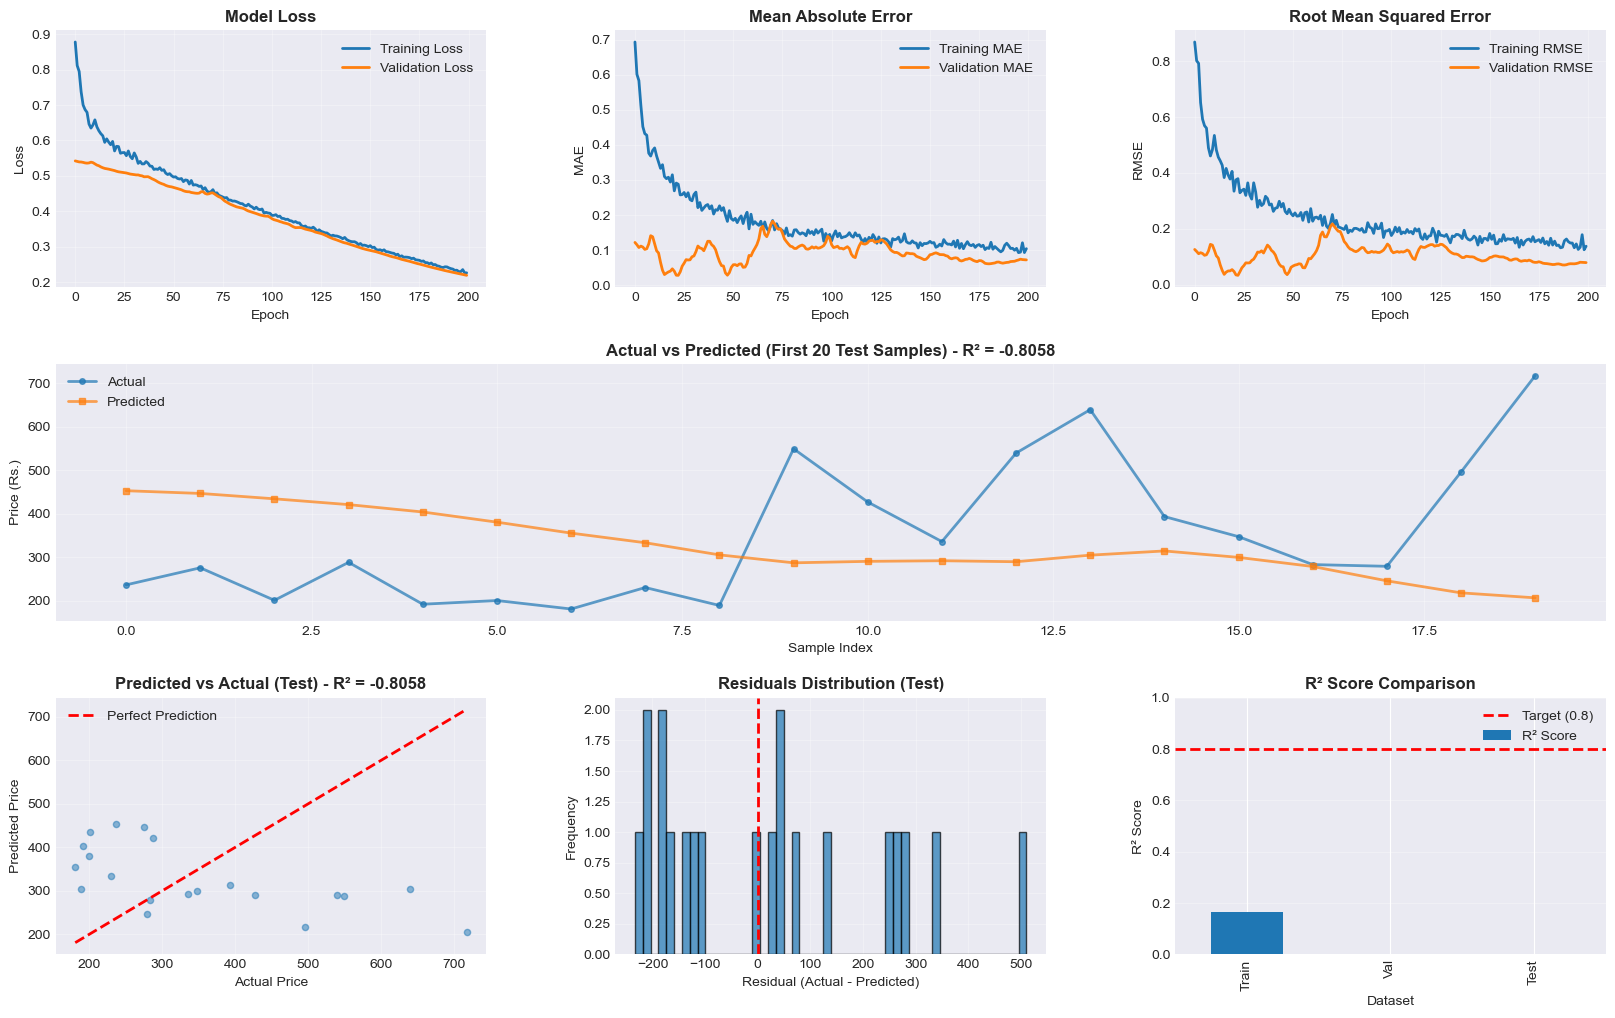


✓ Visualizations saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\enhanced_training_20260301_114456


In [26]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Training History - Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Training History - MAE
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
ax2.set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training History - RMSE
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(history.history['rmse'], label='Training RMSE', linewidth=2)
ax3.plot(history.history['val_rmse'], label='Validation RMSE', linewidth=2)
ax3.set_title('Root Mean Squared Error', fontsize=12, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('RMSE')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Test Set Predictions (First 100 samples)
ax4 = fig.add_subplot(gs[1, :])
sample_size = min(100, len(y_test_actual))
ax4.plot(y_test_actual[:sample_size], label='Actual', marker='o', markersize=4, linewidth=2, alpha=0.7)
ax4.plot(y_pred_test_actual[:sample_size], label='Predicted', marker='s', markersize=4, linewidth=2, alpha=0.7)
ax4.set_title(f'Actual vs Predicted (First {sample_size} Test Samples) - R² = {test_r2:.4f}', 
             fontsize=12, fontweight='bold')
ax4.set_xlabel('Sample Index')
ax4.set_ylabel('Price (Rs.)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Scatter Plot - Predicted vs Actual (Test Set)
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(y_test_actual, y_pred_test_actual, alpha=0.5, s=20)
min_val = min(y_test_actual.min(), y_pred_test_actual.min())
max_val = max(y_test_actual.max(), y_pred_test_actual.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax5.set_title(f'Predicted vs Actual (Test) - R² = {test_r2:.4f}', fontsize=12, fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Residuals Distribution (Test Set)
ax6 = fig.add_subplot(gs[2, 1])
residuals = y_test_actual.flatten() - y_pred_test_actual.flatten()
ax6.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax6.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax6.set_title('Residuals Distribution (Test)', fontsize=12, fontweight='bold')
ax6.set_xlabel('Residual (Actual - Predicted)')
ax6.set_ylabel('Frequency')
ax6.grid(True, alpha=0.3)

# 7. Metrics Comparison Bar Chart
ax7 = fig.add_subplot(gs[2, 2])
metrics_comparison = pd.DataFrame({
    'Train': [train_r2],
    'Val': [val_r2],
    'Test': [test_r2]
}, index=['R² Score'])
metrics_comparison.T.plot(kind='bar', ax=ax7, legend=False)
ax7.axhline(y=0.8, color='r', linestyle='--', linewidth=2, label='Target (0.8)')
ax7.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
ax7.set_ylabel('R² Score')
ax7.set_xlabel('Dataset')
ax7.set_ylim(0, 1.0)
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

plt.savefig(log_dir / 'comprehensive_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations saved to: {log_dir}")

## 13. Feature Importance Analysis

In [27]:
# Analyze which features contribute most to predictions
# Using permutation importance concept

print("Feature Statistics:")
print("=" * 60)

feature_stats = pd.DataFrame({
    'Feature': feature_cols,
    'Mean': df_enhanced[feature_cols].mean(),
    'Std': df_enhanced[feature_cols].std(),
    'Min': df_enhanced[feature_cols].min(),
    'Max': df_enhanced[feature_cols].max()
})

print(f"\nTop 10 features by variance:")
feature_stats_sorted = feature_stats.sort_values('Std', ascending=False)
print(feature_stats_sorted.head(10))

# Save feature statistics
feature_stats_path = log_dir / 'feature_statistics.csv'
feature_stats_sorted.to_csv(feature_stats_path, index=False)
print(f"\n✓ Feature statistics saved to: {feature_stats_path}")

Feature Statistics:

Top 10 features by variance:
                   Feature          Mean           Std           Min  \
OBV                    OBV  1.630476e+06  1.224038e+06  66644.000000   
Volume              Volume  1.172981e+05  9.863886e+04  10327.000000   
Volume_MA_7    Volume_MA_7  1.157232e+05  8.551454e+04  15868.285714   
Volume_MA_14  Volume_MA_14  1.140492e+05  8.154829e+04  17319.071429   
BB_Width          BB_Width  7.416540e+02  5.862792e+02    201.589919   
BB_Upper          BB_Upper  7.948641e+02  5.691104e+02    174.833384   
Momentum_10    Momentum_10  1.610294e+01  3.833042e+02  -1611.488900   
Close_Lag_7    Close_Lag_7  4.273526e+02  3.653505e+02     47.447761   
Close_Lag_5    Close_Lag_5  4.304608e+02  3.648420e+02     47.447761   
Close_Lag_3    Close_Lag_3  4.325694e+02  3.635140e+02     47.447761   

                       Max  
OBV           3.841320e+06  
Volume        6.177500e+05  
Volume_MA_7   4.029231e+05  
Volume_MA_14  3.902780e+05  
BB_Width    

## 14. Final Summary

In [28]:
print("\n" + "=" * 80)
print("ENHANCED MODEL TRAINING SUMMARY")
print("=" * 80)

print(f"\n Model Configuration:")
print(f"   - Architecture: Deep LSTM with {config.model.lstm_units} units")
print(f"   - Input Features: {X_train.shape[2]} technical indicators")
print(f"   - Sequence Length: {config.preprocessing.sequence_length}")
print(f"   - Total Parameters: {model.count_params():,}")

print(f"\n Performance Metrics:")
print(f"   - Test R² Score: {test_r2:.4f} {'✓ Target Achieved!' if test_r2 >= 0.8 else '(Target: > 0.8)'}")
print(f"   - Test RMSE: {test_rmse:.4f}")
print(f"   - Test MAE: {test_mae:.4f}")
print(f"   - Test MAPE: {test_mape:.2f}%")

print(f"\n Saved Artifacts:")
print(f"   - Model: {model_save_path}")
print(f"   - Best Checkpoint: {checkpoint_dir / 'best_model.keras'}")
print(f"   - Scalers: {scaler_dir}")
print(f"   - Logs & Metrics: {log_dir}")

if test_r2 < 0.8:
    print(f"\n Recommendations to improve R² further:")
    print(f"   1. Train for more epochs")
    print(f"   2. Try ensemble methods (combine multiple models)")
    print(f"   3. Experiment with different sequence lengths")
    print(f"   4. Add more external features (market indices, sentiment)")
    print(f"   5. Try hybrid CNN-LSTM architecture")

print("\n✓ Enhanced model training completed successfully!")
print("=" * 80)


ENHANCED MODEL TRAINING SUMMARY

 Model Configuration:
   - Architecture: Deep LSTM with [128, 128, 64, 32] units
   - Input Features: 40 technical indicators
   - Sequence Length: 30
   - Total Parameters: 282,945

 Performance Metrics:
   - Test R² Score: -0.8058 (Target: > 0.8)
   - Test RMSE: 211.0709
   - Test MAE: 175.9280
   - Test MAPE: 54.29%

 Saved Artifacts:
   - Model: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models_enhanced\enhanced_lstm_model_20260301_114801.keras
   - Best Checkpoint: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints_enhanced\best_model.keras
   - Scalers: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\scalers_enhanced
   - Logs & Metrics: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\enhanced_training_20260301_114456

 Recommendations to improve R